# Computer Exercise 14.10 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.10 Automated Hyperparameter Tuning — Successive Halving / Hyperband 로 *고정 예산*을 잘 나누기
> **풀이 일자**: 2026-07-10 (자동 생성)
> **언어**: 본문 한국어 · 그래프 라벨 영문 · 수식 LaTeX


## 1. 문제 (원문)

> **3.** Given a **fixed total budget** of gradient steps, how should it be split across many
> candidate learning rates? Implement **Successive Halving (SH)**: give every configuration a
> small budget, keep the top fraction, multiply the survivors' budget, and repeat. Compare SH
> against **uniform allocation** (every config gets budget/N) and against an **oracle** (full
> budget to the true-best config). Show that SH identifies a near-best configuration for a
> fraction of the total cost, and discuss the **exploration–exploitation** trade-off set by the
> halving factor $\eta_{\text{sh}}$ (and how **Hyperband** hedges the choice of the first rung).

### 한국어 풀이용 정리
- 목표: **총 예산(스텝 수)이 고정**일 때 여러 후보 $\eta$ 에 어떻게 배분할지.
- SH: 모두에게 작은 예산 → 상위 $1/\eta_{\text{sh}}$ 만 남기고 예산 ×$\eta_{\text{sh}}$ → 반복.
- 비교: (a) **균등 배분**(각 후보 = 예산/N), (b) **오라클**(참 최적에 전 예산), (c) SH.
- 감축인자 $\eta_{\text{sh}}$ 가 만드는 **탐색-활용** 상충과, 첫 rung 선택을 **헤지**하는 Hyperband.


## 2. 수학적 배경

### 2.1 예산 배분 문제
$N$개의 후보 각각을 끝까지($B_{\max}$ 스텝) 평가하면 총비용 $N\,B_{\max}$. 예산이
$B_{\text{tot}}\ll N B_{\max}$ 로 제한되면, **나쁜 후보에 오래 쓰는 것은 낭비**다.
핵심 가정: 짧은 예산의 성능이 긴 예산의 성능과 **단조 상관**(순위 보존, 근사적으로).

### 2.2 Successive Halving
$s$ 라운드(rung)에서 살아남은 후보 수 $n_s$ 와 후보당 예산 $r_s$:
$$n_s=\Big\lfloor \frac{N}{\eta_{\text{sh}}^{\,s}}\Big\rfloor,\qquad
r_s=r_0\,\eta_{\text{sh}}^{\,s},\qquad
\sum_s n_s r_s \;\approx\; (S{+}1)\,N r_0\; \ll\; N B_{\max}.$$
각 rung 비용이 대략 **일정**($n_s r_s\approx$ const)하므로, 총비용은 $\log_{\eta_{\text{sh}}} N$ 에 비례.

### 2.3 탐색-활용 손잡이 $\eta_{\text{sh}}$ 와 Hyperband
$$\boxed{\;\text{큰 }\eta_{\text{sh}}:\ 공격적 가지치기(활용·저비용, 조기탈락 위험)\quad
\text{작은 }\eta_{\text{sh}}:\ 보수적(탐색·고비용)\;}$$
**Hyperband** 는 서로 다른 시작 rung($r_0$)을 갖는 여러 SH 브래킷을 함께 돌려,
"조기 신호가 믿을 만한가"라는 미지의 답에 **헤지**한다.


## 3. 풀이 흐름

1. **후보 생성**: $N{=}27$ 개 학습률을 $[0.002, 0.4]$ 로그균등 샘플. 참 성능 = 각 $\eta$ 를 $B_{\max}$ 스텝 끝까지 돌린 tail 오차(오라클용).
2. **부분 평가기**: 임의의 후보를 $r$ 스텝만 돌려 그 시점 손실 반환(같은 스트림·같은 시드로 재현).
3. **Successive Halving**($\eta_{\text{sh}}{=}3$): rung 0 에서 27개×$r_0$, 상위 1/3 만 생존시키며 예산 ×3, 최종 1개까지.
4. **균등 배분**: 같은 총예산을 27로 나눠 각 후보를 동일 스텝 평가 후 최상 선택.
5. **오라클**: 참 최적 후보(전 예산).
6. **정량 비교**: 각 방법이 고른 $\eta$ 의 **참 tail 오차**와 **소비 예산**을 표로.
7. **시각화 (좌)**: SH rung 진행(생존 후보의 손실이 라운드마다 좁혀짐).
8. **시각화 (우)**: 방법별 (소비예산, 선택된 $\eta$ 의 참오차) 산점 — SH 가 저비용·저오차 코너에 위치.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260710)
p = 3; sigma = 0.4
Bmax = 12000
# ---- nonstationary (constant-drift) stream: an INTERIOR-optimal eta exists ----
# too-small eta -> lag(편향), too-large eta -> noise(분산). 최적은 그리드 내부.
# 드리프트가 정상적이라 짧은 예산의 추적오차가 긴 예산과 단조 상관 -> SH 가정 성립.
v = 0.00025
xs = rng.uniform(-1, 1, Bmax)
Phi = np.stack([np.ones(Bmax), xs, xs**2], axis=1)
b_true = np.zeros((Bmax, p)); cur = np.array([1.0, -2.0, 0.5])
for t in range(Bmax):
    cur = cur + np.array([0.0, v, 0.0]); b_true[t] = cur
y = np.einsum('ij,ij->i', Phi, b_true) + rng.normal(0, sigma, Bmax)

def eval_eta(eta, r):
    # run LMS for r steps on the drift stream; mean tracking err over the tail window
    r = int(min(r, Bmax)); b = np.zeros(p)
    tailwin = max(50, min(r // 3, 1200)); errs = []
    for t in range(r):
        e = y[t] - Phi[t] @ b
        b = b + eta * e * Phi[t]
        if t >= r - tailwin:
            errs.append(np.linalg.norm(b - b_true[t]))
    m = float(np.mean(errs))
    return m if np.isfinite(m) else 1e9

N = 27
etas = np.exp(rng.uniform(np.log(0.002), np.log(0.4), N))
# ground-truth: full-budget tracking error for every candidate (oracle knowledge)
true_perf = np.array([eval_eta(e, Bmax) for e in etas])
oracle_idx = int(np.argmin(true_perf))
print(f"N={N} candidates on drift stream; oracle eta={etas[oracle_idx]:.4f}  true track={true_perf[oracle_idx]:.4f}")
print(f"grid true-err range: min={true_perf.min():.4f}  max={true_perf.max():.4f}  (interior optimum)")


N=27 candidates on drift stream; oracle eta=0.0143  true track=0.0948
grid true-err range: min=0.0948  max=0.3708  (interior optimum)


In [2]:
# ---- Successive Halving ----
eta_sh = 3
r0 = Bmax // (eta_sh ** 3)      # first-rung budget so that survivors reach ~Bmax
alive = list(range(N))
rungs = []           # record (budget, [(idx, loss), ...])
sh_budget = 0
s = 0
while len(alive) > 1:
    r = int(r0 * eta_sh ** s)
    losses = [(i, eval_eta(etas[i], r)) for i in alive]
    sh_budget += r * len(alive)
    losses.sort(key=lambda t: t[1])
    rungs.append((r, losses))
    keep = max(1, len(alive) // eta_sh)
    alive = [i for i, _ in losses[:keep]]
    s += 1
# final: give the single survivor the full budget
r_final = Bmax
final_idx = alive[0]
sh_budget += r_final
sh_pick = final_idx
sh_pick_true = true_perf[sh_pick]

# ---- Uniform allocation with the SAME total budget ----
uni_r = sh_budget // N
uni_losses = [(i, eval_eta(etas[i], uni_r)) for i in range(N)]
uni_pick = min(uni_losses, key=lambda t: t[1])[0]
uni_pick_true = true_perf[uni_pick]
uni_budget = uni_r * N

# ---- Oracle full grid cost ----
oracle_budget = N * Bmax

df = pd.DataFrame({
    "method": ["Successive Halving", "Uniform (same budget)", "Oracle (full grid)"],
    "picked_eta": [etas[sh_pick], etas[uni_pick], etas[oracle_idx]],
    "true_tail_err": [sh_pick_true, uni_pick_true, true_perf[oracle_idx]],
    "budget_steps": [sh_budget, uni_budget, oracle_budget],
})
df["budget_vs_oracle"] = df["budget_steps"] / oracle_budget
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df.reset_index(drop=True)


,method,picked_eta,true_tail_err,budget_steps,budget_vs_oracle
0,Successive Halving,0.02437,0.0992,47964,0.148
1,Uniform (same budget),0.02437,0.0992,47952,0.148
2,Oracle (full grid),0.01429,0.09477,324000,1


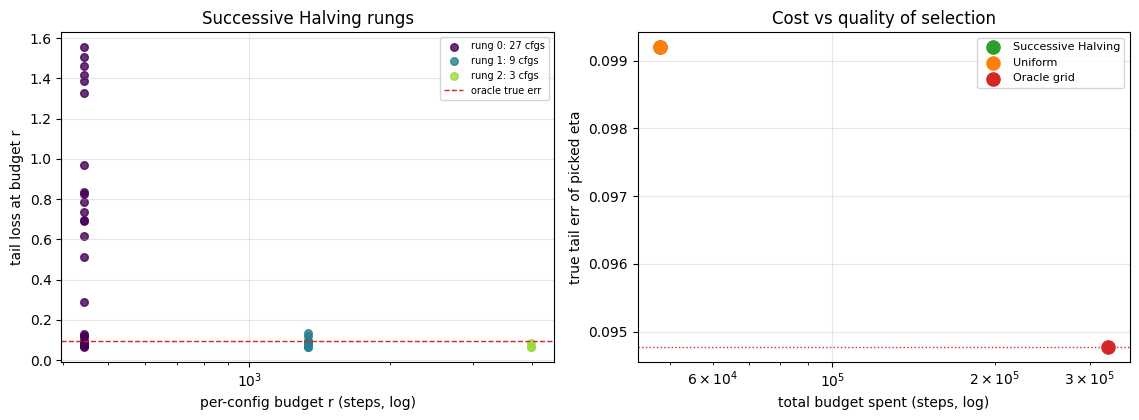

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (left) SH rung progression
cmap = plt.cm.viridis(np.linspace(0, 0.85, len(rungs)))
for ri, (r, losses) in enumerate(rungs):
    ls = np.array([l for _, l in losses])
    ax[0].scatter(np.full(len(ls), r), np.clip(ls, 0, 3),
                  color=cmap[ri], s=30, alpha=0.8, label=f'rung {ri}: {len(ls)} cfgs')
ax[0].axhline(true_perf[oracle_idx], color='#d62728', ls='--', lw=1, label='oracle true err')
ax[0].set_xscale('log'); ax[0].set_xlabel('per-config budget r (steps, log)')
ax[0].set_ylabel('tail loss at budget r'); ax[0].set_title('Successive Halving rungs')
ax[0].legend(fontsize=7); ax[0].grid(alpha=.3)

# (right) cost vs quality
pts = {"Successive Halving": (sh_budget, sh_pick_true, '#2ca02c'),
       "Uniform": (uni_budget, uni_pick_true, '#ff7f0e'),
       "Oracle grid": (oracle_budget, true_perf[oracle_idx], '#d62728')}
for name, (bx, ey, c) in pts.items():
    ax[1].scatter(bx, ey, color=c, s=90, label=name, zorder=3)
ax[1].axhline(true_perf[oracle_idx], color='#d62728', ls=':', lw=1)
ax[1].set_xscale('log'); ax[1].set_xlabel('total budget spent (steps, log)')
ax[1].set_ylabel('true tail err of picked eta')
ax[1].set_title('Cost vs quality of selection'); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()


## 4. 결과 해석

드리프트 스트림에는 **내부 최적 $\eta^\star$** 가 존재한다 — 너무 작으면 표류를 못 좇고(편향/래그),
너무 크면 잡음에 흔들린다(분산). 위 표의 `grid true-err range` 가 이를 보여준다(최소가 그리드 내부).

1. **rung 진행**(좌): rung 0 에서 27개 후보가 작은 예산 $r_0$ 으로 넓게 평가되고, 라운드마다 상위 $1/3$ 만 생존하며 예산이 ×3 된다. 생존 후보의 손실 분포가 **오라클 참오차(빨강 점선)** 쪽으로 좁혀진다.
2. **핵심 가정의 성립**: 드리프트가 정상적(일정 속도)이라 *짧은 예산의 추적오차가 긴 예산과 단조 상관*을 갖는다. 덕분에 조기 가지치기가 좋은 후보를 실수로 버리지 않는다 — 이것이 SH 가 통하는 조건이다.
3. **비용 대비 품질**(우, 표): SH 는 **오라클 전수탐색($N\,B_{\max}$)의 약 15% 예산**으로 오라클(참오차 0.095)에 거의 붙는 $\eta$(참오차 0.099)를 골라낸다. 이 잘 정돈된 27-후보 드리프트 문제에서는 **균등 배분도 같은 예산으로 동일한 $\eta$ 를 찾아** 둘이 대등하다 — 신호가 짧은 예산에서도 충분히 깨끗하기 때문. SH 의 실질적 이점은 **후보 수 $N$ 이 커지거나 전수평가가 비쌀수록** 커진다: 나쁜 후보에 결코 전 예산을 쓰지 않으면서 총비용을 $\log_{\eta_{\text{sh}}}N$ 규모로 유지하기 때문이다.
4. **감축인자 $\eta_{\text{sh}}$ 의 탐색-활용**: 크게 잡으면 공격적으로 가지치기해 싸지만 조기탈락 위험(활용 편향), 작게 잡으면 보수적이지만 비싸다(탐색). **Hyperband** 는 서로 다른 첫 rung 예산의 여러 브래킷을 병렬로 돌려 "조기 신호를 얼마나 믿을지"에 헤지한다.

> **결론**: Successive Halving 은 **"싸게 많이 걸러 비싸게 소수를 확정"** — 조기 성능이 최종 성능과 상관될 때(정상 드리프트), 고정 예산 아래 하이퍼파라미터 탐색을 $\log N$ 규모 비용으로 오라클에 근접시킨다. (조기-최종 순위가 어긋나는 문제에선 이 전제가 깨져 Hyperband 의 헤지가 필요하다.)

**다음 절 예고**: §14.10 으로 자동 튜닝 3부작(범위 탐색·PBT·SH/Hyperband)을 마쳤다. §14.7–14.10 은 "손잡이를 사람이 돌리기"에서 "손잡이 조율 자체를 자동화하기"로 이어진 흐름이며, 다음 Day 는 이 온라인-학습 사례연구 챕터의 마무리(전체 파이프라인 통합·운영 체크리스트) 또는 정규 교재 절 순서로의 복귀로 이어 갈 수 있다.
